In [ ]:
# ======================================================
# 🧩 1. IMPORTS & INITIAL SETUP
# ======================================================
import os
import sys
import csv
import importlib
from datetime import datetime
from PIL import ImageFile
from google.colab import drive

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
import numpy as np

# FIX TRUNCATED/CORRUPTED IMAGES
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ======================================================
# 🌐 2. LOAD LOCAL PREPROCESSING SCRIPT
# ======================================================
PREPROCESSING_PATH = '/content/preprocessing_leukemia_cnn.py'
sys.path.append(os.path.dirname(PREPROCESSING_PATH))

import preprocessing_leukemia_cnn
importlib.reload(preprocessing_leukemia_cnn)
from preprocessing_leukemia_cnn import preprocess_leukemia_dataset

# ======================================================
# 💾 3. MOUNT GOOGLE DRIVE
# ======================================================
drive.mount('/content/drive')

# DEFINE PATHS
RAW_DATA_DIR = '/content/drive/MyDrive/Research/DataFolder'
DEST_DIR = '/content/drive/MyDrive/Research/leukemia_cleaned_cnn'
RESULTS_DIR = '/content/drive/MyDrive/Research/Results_cnn'
LOG_FILE = os.path.join(RESULTS_DIR, 'training_logs.csv')

os.makedirs(DEST_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ======================================================
# 🧼 4. RUN PREPROCESSING
# ======================================================
train_gen, val_gen, test_gen = preprocess_leukemia_dataset(
    input_path=RAW_DATA_DIR,
    output_path=DEST_DIR,
    img_size=(128, 128),
    batch_size=32
)

# ======================================================
# 🏗️ 5. MODEL DEVELOPMENT (CNN)
# ======================================================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # binary: 1 unit with sigmoid
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='Precision'), Recall(name='Recall')]
)

model.summary()


Mounted at /content/drive
✅ Dataset reorganized into: ['ALLNeg', 'ALLPos', 'train', 'val', 'test']
✅ Data split into train / val / test folders.
Found 2973 images belonging to 2 classes.
Found 917 images belonging to 2 classes.
Found 906 images belonging to 2 classes.
✅ Generators ready.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,185 (24.86 MB)

 Trainable params: 6,516,737 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ======================================================
# 🚀 6. TRAINING
# ======================================================
checkpoint_path = os.path.join(RESULTS_DIR, 'best_leukemia_model.keras')

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - Precision: 0.8569 - Recall: 0.8559 - accuracy: 0.7586 - loss: 2.7360
Epoch 1: val_accuracy improved from -inf to 0.76990, saving model to /content/drive/MyDrive/Research/Results_cnn/best_leukemia_model.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 418s 4s/step - Precision: 0.8570 - Recall: 0.8564 - accuracy: 0.7590 - loss: 2.7218 - val_Precision: 0.8359 - val_Recall: 0.9059 - val_accuracy: 0.7699 - val_loss: 3.3430
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - Precision: 0.8588 - Recall: 0.9889 - accuracy: 0.8526 - loss: 0.3527
Epoch 2: val_accuracy improved from 0.76990 to 0.84515, saving model to /content/drive/MyDrive/Research/Results_cnn/best_leukemia_model.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 310ms/step - Precision: 0.8588 - Recall: 0.9889 - accuracy: 0.8526 - loss: 0.3527 - val_Precision: 0.8461 - val_Recall: 0.9987 - val_accuracy: 0.8451 - val_loss: 5.3761
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - Precision: 0.8921 - Reca

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - Precision: 0.9809 - Recall: 0.9912 - accuracy: 0.9764 - loss: 0.0562
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step
✅ Validation ROC-AUC: 0.4801

✅ Validation Accuracy: 97.71%
✅ F1 Score: 0.9865, ROC-AUC: 0.4801
✅ Metrics logged to /content/drive/MyDrive/Research/Results_cnn/training_logs.csv


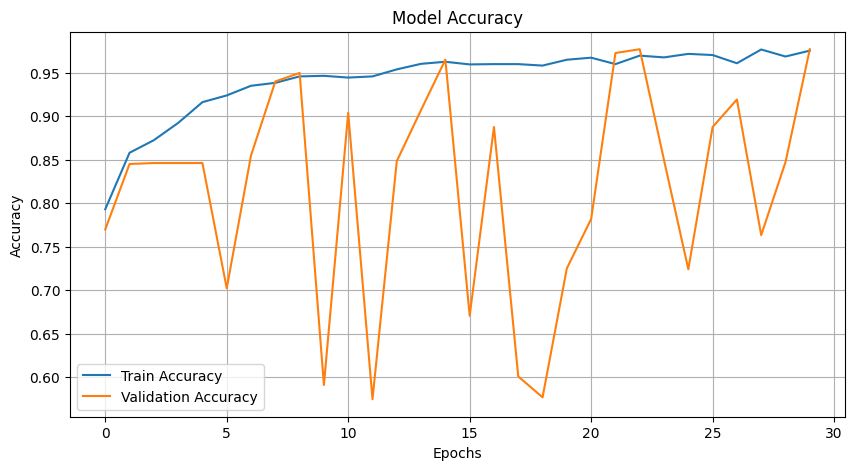

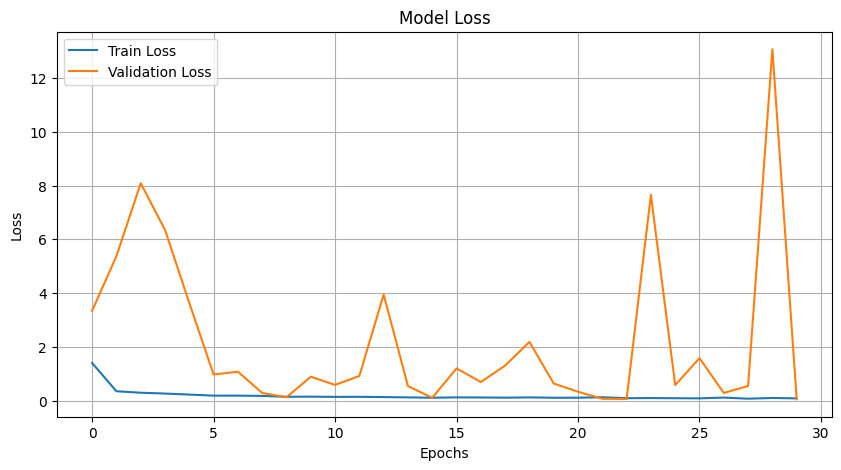

✅ Final model saved at: /content/drive/MyDrive/Research/Results_cnn/leukemia_final_model.keras


In [ ]:
# ======================================================
# 🧪 7. EVALUATION
# ======================================================
test_loss, test_acc, test_precision, test_recall = model.evaluate(val_gen)
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-7)

# ROC-AUC
from sklearn.metrics import roc_auc_score

# 🔹 Predict probabilities
y_pred_probs = model.predict(val_gen)

# 🔹 True labels
y_true = val_gen.classes

# 🔹 Compute binary ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_probs)

print(f"✅ Validation ROC-AUC: {roc_auc:.4f}")

print(f"\n✅ Validation Accuracy: {test_acc*100:.2f}%")
print(f"✅ F1 Score: {test_f1:.4f}, ROC-AUC: {roc_auc:.4f}")

# ======================================================
# 📊 8. LOG TRAINING RESULTS TO CSV
# ======================================================
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def safe_get(metric):
    return history.history.get(metric, [None])[-1]

row = [
    timestamp,
    safe_get('accuracy'),
    safe_get('val_accuracy'),
    safe_get('loss'),
    safe_get('val_loss'),
    safe_get('Precision'),
    safe_get('val_Precision'),
    safe_get('Recall'),
    safe_get('val_Recall'),
    max(history.history.get('val_accuracy', [0])),
    min(history.history.get('val_loss', [999])),
    test_acc, test_loss, test_precision, test_recall, test_f1, roc_auc,
    len(history.history.get('accuracy', [])),
    (safe_get('accuracy') or 0) - (safe_get('val_accuracy') or 0),
    model.count_params()
]

if not os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        header = ['Timestamp','Train_Acc','Val_Acc','Train_Loss','Val_Loss',
                  'Train_Precision','Val_Precision','Train_Recall','Val_Recall',
                  'Best_Val_Acc','Best_Val_Loss',
                  'Test_Acc','Test_Loss','Test_Precision','Test_Recall','Test_F1','Test_ROC_AUC',
                  'Epochs_Trained','Overfitting_Gap','Total_Params']
        writer.writerow(header)
        writer.writerow(row)
else:
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(row)

print(f"✅ Metrics logged to {LOG_FILE}")

# ======================================================
# 📈 9. VISUALIZE RESULTS
# ======================================================
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# ======================================================
# 💾 10. SAVE FINAL MODEL (.keras FORMAT)
# ======================================================
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, 'leukemia_final_model.keras')
model.save(FINAL_MODEL_PATH)
print(f"✅ Final model saved at: {FINAL_MODEL_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted.
Please upload an image file:


Saving 11.jpg to 11 (1).jpg
User uploaded file "11 (1).jpg"
✅ Model loaded from: /content/drive/MyDrive/Research/Results_cnn/leukemia_final_model.keras


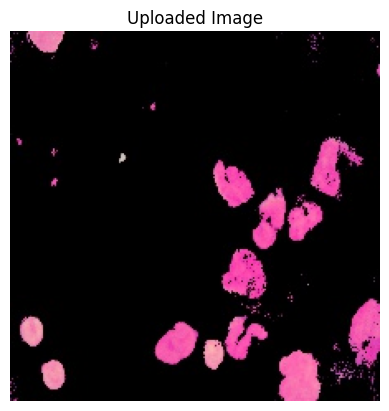

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step

Prediction: ALL Negative (Confidence: 0.90)


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files, drive # Import drive here
from PIL import Image
import io
import os
import matplotlib.pyplot as plt # Import matplotlib for displaying images

# Ensure RESULTS_DIR and FINAL_MODEL_PATH are defined
# (These would typically be defined earlier in the notebook, e.g., in cell_id: _zBgcEp5vinq)
# If you rerun this cell independently, ensure these paths are correctly set.
# For example:
RESULTS_DIR = '/content/drive/MyDrive/Research/Results_cnn'
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, 'leukemia_final_model.keras')

# ======================================================
# 💾 Ensure Google Drive is mounted
# ======================================================
drive.mount('/content/drive')
print("✅ Google Drive mounted.")

# ======================================================
# 📥 UPLOAD IMAGE FOR PREDICTION
# ======================================================
print("Please upload an image file:")
uploaded = files.upload()

img_path_bytes = None
for fn in uploaded.keys():
    print(f"User uploaded file \"{fn}\"")
    img_path_bytes = io.BytesIO(uploaded[fn])
    break # Assuming only one file is uploaded for single image prediction

if img_path_bytes is None:
    print("No file uploaded. Please upload an image to proceed.")
else:
    # ======================================================
    # 🛠️ LOAD THE BEST MODEL
    # ======================================================
    loaded_model = tf.keras.models.load_model(FINAL_MODEL_PATH)
    print(f"✅ Model loaded from: {FINAL_MODEL_PATH}")

    # ======================================================
    # 🔄 PREPROCESS AND PREDICT SINGLE IMAGE
    # ======================================================

    # Load and preprocess the image
    img = Image.open(img_path_bytes)

    # Display the uploaded image
    plt.imshow(img)
    plt.title('Uploaded Image')
    plt.axis('off')
    plt.show()

    img = img.resize((128, 128)) # Resize to the target input size of the model
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array /= 255.0  # Rescale the image like the training data

    # Make prediction
    prediction = loaded_model.predict(img_array)

    # Interpret the prediction
    if prediction[0][0] > 0.5:
        result = "ALL Positive"
        confidence = prediction[0][0]
    else:
        result = "ALL Negative"
        confidence = 1 - prediction[0][0]

    print(f"\nPrediction: {result} (Confidence: {confidence:.2f})")
